TT ML
Pre-entrega

In [59]:
# Importar paquetes
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [60]:
# 1. Selección y carga del dataset

file_path = "diabetes.csv"
print("Descargando datos desde National Institute of Diabetes and Digestive and Kidney Diseases...")

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/pima-indians-diabetes-database",
  file_path
)

# Revisar carga correcta

df.head()


Descargando datos desde National Institute of Diabetes and Digestive and Kidney Diseases...


/tmp/ipykernel_791/510013310.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Análisis de Datos Exploratorio

In [61]:
# 2. Exploración inicial: selección de variables relevantes
# Dado que son solo 8 columnas con información médica relevante, se usan todas.

print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


#### En este conjunto de datos, la variable dependiente es 'Outcome' y las otras ocho variables ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age') son independientes.

In [62]:
# 3. Limpieza de datos nulos o faltantes.

#Buscar valores nulos
print("¿Hay valores nulos?", df.isnull().values.any())

#Ver cantidad de instancias/filas
print(f"Hay {len(df)} filas no nulas.")

#Eliminar valores nulos que hubiera sin identificar.
df_diabetes = df.dropna()

print(f"La df_diabetes tiene información limpia de {len(df_diabetes)} casos.")

¿Hay valores nulos? False
Hay 768 filas no nulas.
La df_diabetes tiene información limpia de 768 casos.


# Estadística descriptiva

In [63]:
# Valores estadísticos generales de la df_diabetes
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Observaciones parciales:
- El valor mínimo para 7 de las 8 variables independientes es 0.
- Mchos de estos valores corresponden a niveles de insulina, glucosa, presión arterial (BP), índice de masa corporal (BMI), etc. que no pueden ser nulos.
- Parece que varios valores faltantes o erróneos fueron imputados como 0.

In [64]:
# ¿Cuántos valores nulos aparecen en cada variable/columna?
print(f"Total de valores 0 por columna {(df_diabetes == 0).sum().to_dict()}")

Total de valores 0 por columna {'Pregnancies': 111, 'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11, 'DiabetesPedigreeFunction': 0, 'Age': 0, 'Outcome': 500}


####
- Quitar datos con valores 0 de glucosa, presión arterial, IMC e insulina.
- Crear un nuevo dataset antes de continuar el análisis.


In [65]:
# Creación de nuevo dataset
# df_diabs que excluye todas las filas que tienen valor 0 en las columnas
# Glucose, BP, BMI y Insulin

drop_Glu=df_diabetes.index[df_diabetes.Glucose == 0].tolist()
drop_BP=df_diabetes.index[df_diabetes.BloodPressure == 0].tolist()
drop_Ins = df_diabetes.index[df_diabetes.Insulin==0].tolist()
drop_BMI = df_diabetes.index[df_diabetes.BMI==0].tolist()

c= drop_Glu + drop_BP + drop_Ins + drop_BMI

df_diabs=df_diabetes.drop(df_diabetes.index[c])

print(df_diabs.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               392 non-null    int64  
 1   Glucose                   392 non-null    int64  
 2   BloodPressure             392 non-null    int64  
 3   SkinThickness             392 non-null    int64  
 4   Insulin                   392 non-null    int64  
 5   BMI                       392 non-null    float64
 6   DiabetesPedigreeFunction  392 non-null    float64
 7   Age                       392 non-null    int64  
 8   Outcome                   392 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 30.6 KB
None


####
- La df original se redujo casi a la mitad pero df_diabs es mucho más informativa porque contiene datos más relevantes para el modelado.
- Alternativa: se pueden tomar esos 0 como NaN (valores faltantes) y se pueden imputar usando KNN o imputandolos con las medianas para crear un dataset más balanceado.

In [66]:
# Valores estadísticos generales de la df_diabs
df_diabs.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


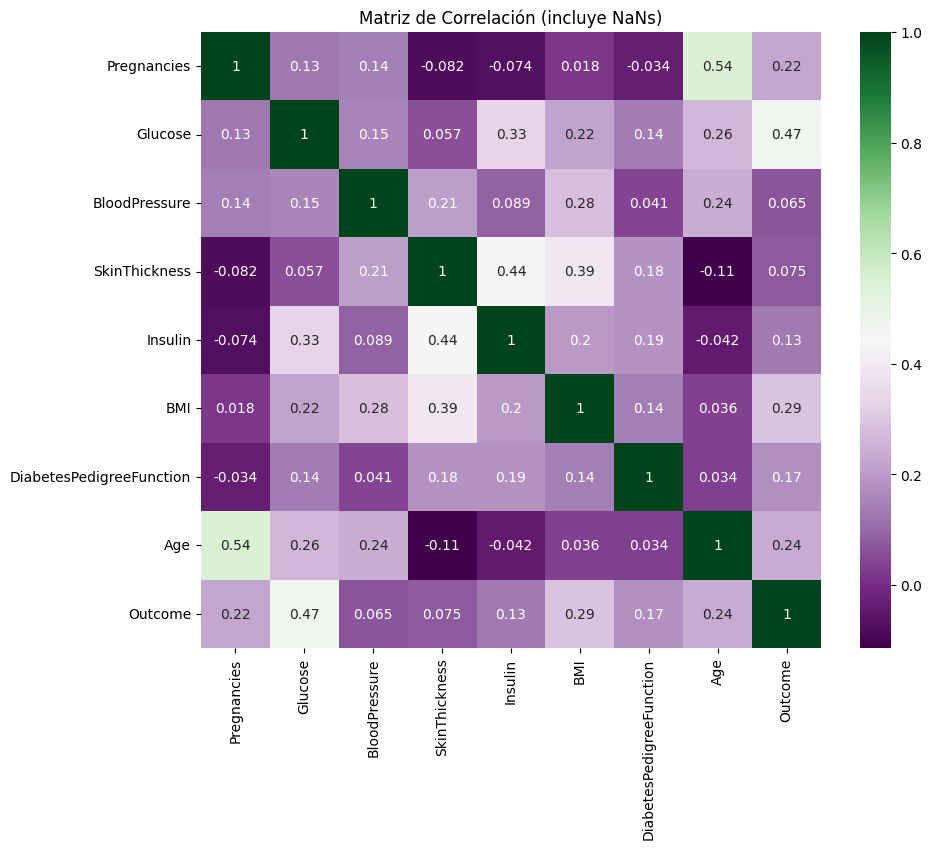

In [67]:
# Exploración visual inicial (matriz de correlación)

#Con la df original (df_diabetes), que incluye todos los valores 0:
plt.figure(figsize=(10, 8))
sns.heatmap(df_diabetes.corr(), annot=True, cmap='PRGn')
plt.title('Matriz de Correlación (incluye NaNs)')
plt.show()

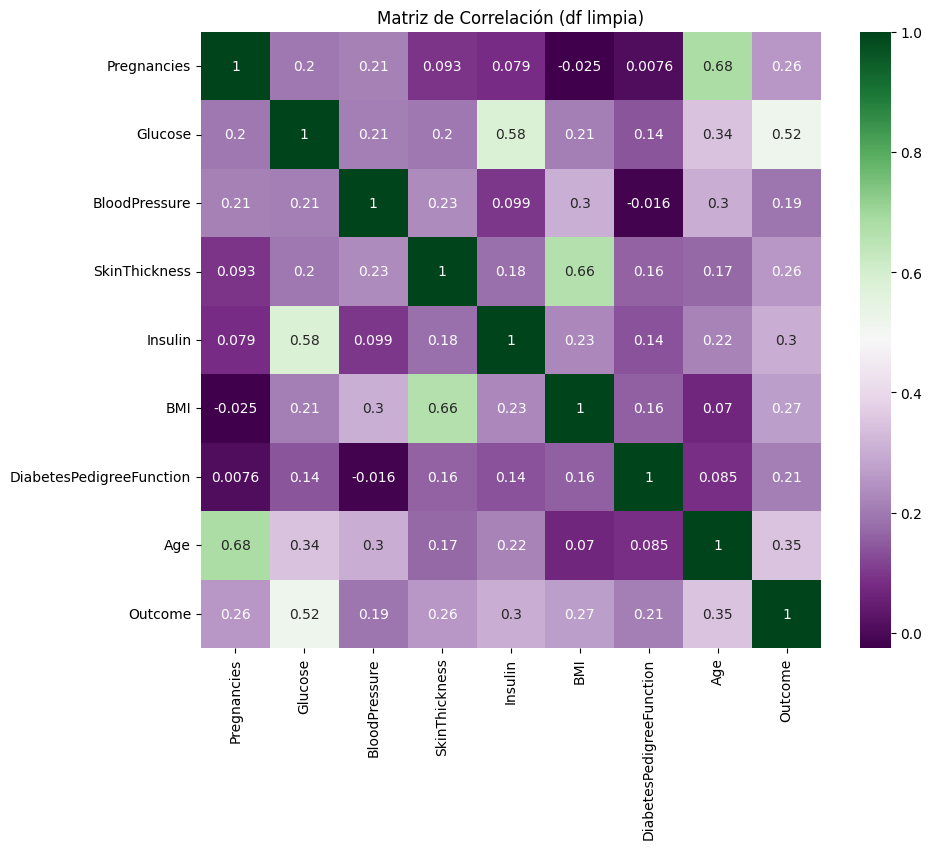

In [68]:
# Exploración visual inicial (matriz de correlación)
# Con la df limpia (df_diabs):
plt.figure(figsize=(10, 8))
sns.heatmap(df_diabs.corr(), annot=True, cmap='PRGn')
plt.title('Matriz de Correlación (df limpia)')
plt.show()


##### Al comparar los dos heatmaps se ve que:
- Los valores 0 de variables relevantes en la df original producen ruido.
- El heatmap de la df inicial esconde correlaciones relevantes que sí se ven en el heatmap de la df limpia.
- Algunas variables ya correlacionadas en la 1era df, aparecen con indices mayores de correlación en la df limpia.

### Preparación de los datos para modelado

#### División del dataset en conjuntos de entrenamiento y prueba.

In [69]:
#columnas =(df_diabs.columns).tolist()
#print(columnas)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación
# Todas las variables (incluyendo la dependiente) son numéricas
# No hace falta codificar variables.

# 2. Separar las pistas (X) del resultado (y)
X = df_diabs[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]

y = df_diabs['Outcome']


# 3. Escalado de variables numéricas
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 4. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)


In [70]:
#### Creación, aprendizaje y evaluación de un modelo de clasificación KNN sobre el dataset.

In [71]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Creación el modelo
knn_diabs = KNeighborsClassifier()

# 2.Aprendizaje: alimentación del modelo con datos de entrenamiento
# Entrenamiento con 5 valores distintos de k entre 3 y 7.

#Creación de listas para guardar los resultados
#de entrenamiento y prueba para cada valor de K
train_scores = []
test_scores = []

# Creación de bucle for para realizar el modelado, entrenamiento y prueba
# para cada valor de K.

for i in range(3,7):
    knn_diabs = KNeighborsClassifier(i)
    knn_diabs.fit(X_train,y_train)
    train_scores.append(knn_diabs.score(X_train, y_train))
    test_scores.append(knn_diabs.score(X_test, y_test))

#Imprimir el valor máximo de la lista de prueba para buscar el K de mejor rendimiento.
max_test_score =max(test_scores)
print(max_test_score)

0.7468354430379747


In [72]:
#Creación de una comprensión de listas (list comprehension) para mostrar
# el valor máximo de prueba y el K correspondiente
test_score_index = [i for i, v in enumerate(test_scores) if v== max_test_score]

print('El puntaje máximo obtenido en prueba es {} % con k = {}'.format(round(max_test_score*100,5),list(map(lambda x: x+1, test_score_index))))

El puntaje máximo obtenido en prueba es 74.68354 % con k = [3, 4]


#### Evaluación del modelo KNN

---REPORTE DE EVALUACIÓN---               precision    recall  f1-score   support

           0       0.77      0.88      0.82        52
           1       0.68      0.48      0.57        27

    accuracy                           0.75        79
   macro avg       0.73      0.68      0.69        79
weighted avg       0.74      0.75      0.73        79



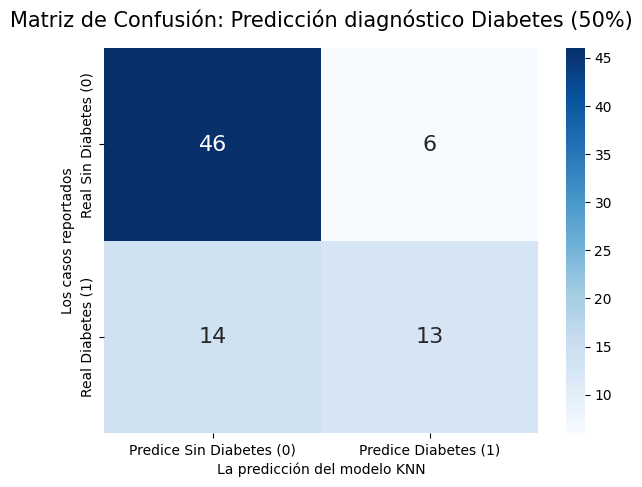

In [73]:
from sklearn.metrics import classification_report, confusion_matrix
#Prueba del modelo KNN
# Generación de predicciones con conjunto de prueba

y_pred = knn_diabs.predict(X_test)

reporte = classification_report(y_test,y_pred)

print("---REPORTE DE EVALUACIÓN---",reporte)

# Visualización del rendimiento del modelo KNN
# usando classification_report y matriz de confusión

cfm_diabs = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cfm_diabs, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Predice Sin Diabetes (0)', 'Predice Diabetes (1)'],
            yticklabels=['Real Sin Diabetes (0)', 'Real Diabetes (1)'])

plt.title('Matriz de Confusión: Predicción diagnóstico Diabetes (50%)', fontsize=15, pad=15)
plt.ylabel('Los casos reportados')
plt.xlabel('La predicción del modelo KNN')
plt.show()

### Observaciones del rendimiento del modelo KNN
#### Hay 14 falsos negativos, lo cual implica que el modelo no pudo predecir 14 casos de diabetes reales.
#### Del total de casos de diabetes, el modelo omitió la mitad +1.

#### Creación, aprendizaje y evaluación de un modelo de regresión logística sobre el mismo dataset.

In [74]:
from sklearn.linear_model import LogisticRegression

# 1. Creación el modelo
logreg_diabs = LogisticRegression()

# 2.Aprendizaje: alimentación del modelo con datos de entrenamiento
logreg_diabs.fit(X_train, y_train)

# 3. Revisión de pesos para ver qué variables consideró más importantes
pesos = pd.DataFrame({
    'Pista de las métricas clínicas': X.columns,
    'Importancia (Peso)': logreg_diabs.coef_[0]
})
print("¿A qué le presta más atención el modelo para detectar diabetes?")
display(pesos)

¿A qué le presta más atención el modelo para detectar diabetes?


,Pista de las métricas clínicas,Importancia (Peso)
0,Pregnancies,0.362659
1,Glucose,1.126297
2,BloodPressure,0.124222
3,SkinThickness,0.221690
4,Insulin,0.131155
5,BMI,0.318195
6,DiabetesPedigreeFunction,0.408242
7,Age,0.199491


#### Evaluación del modelo de regesión logística

---REPORTE DE EVALUACIÓN---               precision    recall  f1-score   support

           0       0.80      0.87      0.83        52
           1       0.70      0.59      0.64        27

    accuracy                           0.77        79
   macro avg       0.75      0.73      0.74        79
weighted avg       0.77      0.77      0.77        79



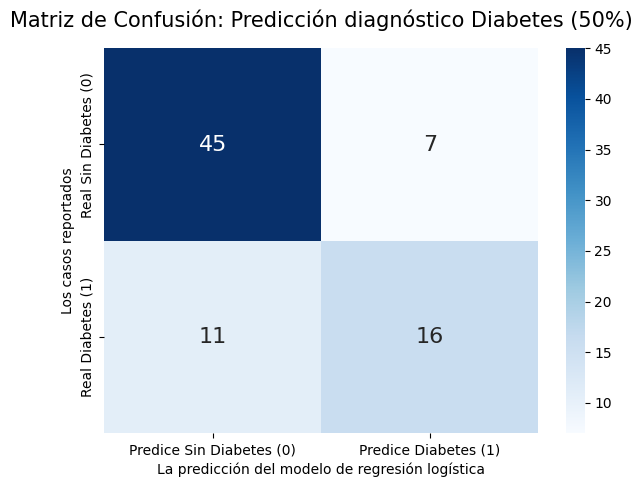

In [75]:
#Prueba del modelo de regresión logística
# Generación de predicciones con conjunto de prueba

y_pred = logreg_diabs.predict(X_test)

report_logreg = classification_report(y_test,y_pred)

print("---REPORTE DE EVALUACIÓN---",report_logreg)

# Visualización del rendimiento del modelo KNN
# usando classification_report y matriz de confusión

cfm_log_diabs = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cfm_log_diabs, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Predice Sin Diabetes (0)', 'Predice Diabetes (1)'],
            yticklabels=['Real Sin Diabetes (0)', 'Real Diabetes (1)'])

plt.title('Matriz de Confusión: Predicción diagnóstico Diabetes (50%)', fontsize=15, pad=15)
plt.ylabel('Los casos reportados')
plt.xlabel('La predicción del modelo de regresión logística')
plt.show()

Observaciones del rendimiento del modelo KNN
Hay 11 falsos negativos, lo cual implica que el modelo no pudo predecir 11 casos de diabetes reales.
Del total de casos de diabetes, el modelo omitió la mitad 11.

#### Visualización de casos reportados con diabetes y sin diabetes

Casos reportados de diabetes: 130
 Casos reportados SIN diabetes: 262


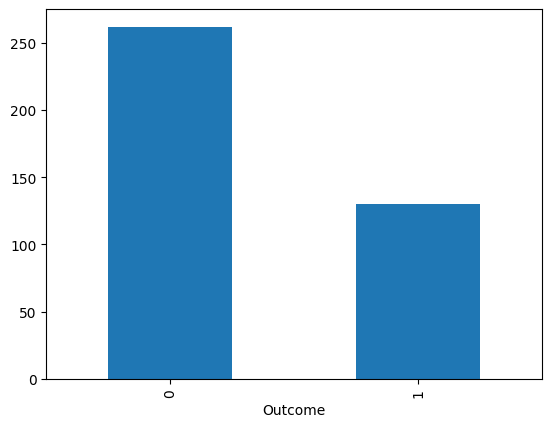

In [87]:
#Contar y mostrar los casos reportados en el dataset limpio.
sin_diabs=len(df_diabs[df_diabs['Outcome']==0])
con_diabs=len(df_diabs[df_diabs['Outcome']==1])

print(f'Casos reportados de diabetes: {con_diabs}\n',f'Casos reportados SIN diabetes: {sin_diabs}')

p=df_diabs.Outcome.value_counts().plot(kind="bar")